# EEG_32 — CSD / Laplaciano di superficie + re-phenotyping

**Domanda scientifica.** L'hypergraph (DHSLP/DHSLF) è *sempre* fallito su questo dataset.
L'ipotesi del collega (vault ClaudeBrain) è che il fallimento sia strutturale: l'hypergraph
fa **diffusione spaziale** su un EEG già "sfocato" dalla **volume conduction**. Sommare
informazione tra elettrodi vicini, quando il segnale è già spazialmente correlato dalla
conduzione di volume, non aggiunge nulla — anzi peggiora il rapporto segnale/rumore.

Il **fix candidato** è lo *spatial sharpening*: la **Current Source Density (CSD)** /
**Laplaciano di superficie**, una trasformazione a riferimento-libero che accentua le sorgenti
locali e attenua i contributi a larga scala della conduzione di volume. È un *one-liner* MNE
(`compute_current_source_density`), quindi a bassissimo effort ma alto valore narrativo.

**Cosa facciamo in questo notebook**
1. **§2** Ricostruiamo il montaggio 61ch da `src/io/ebneuro.locs` (esiste in locale).
2. **§3** Applichiamo la CSD ai trial e confrontiamo PSD/topomap **prima vs dopo** —
   verifica diretta se la **banda beta (13–30 Hz)** sopravvive di più dopo lo sharpening
   (il preprocessing originale la uccide al 98.86%, secondo il collega).
3. **§4** **Re-phenotyping**: ricalcoliamo la connettività `abs_pcc` media per soggetto sui
   dati **CSD** e replichiamo la pipeline di EEG_16b (PCA 20 → KMeans k=2). Confrontiamo i
   nuovi cluster con i fenotipi autorevoli **C0/C1** via ARI e silhouette.
4. **§5** (leggero) decoding lineare `concr4` CSD vs non-CSD, split subject-independent.
5. **§6** Conclusioni attese — ogni esito è informativo.

> **Nota esecuzione.** Questo notebook è scritto sulla macchina di sviluppo ma gira **sul
> server** (env `daniele_311`, porta 8889) dove vivono i dati `data/hypergraphs_pruned_*`.
> Il **montaggio** (`src/io/ebneuro.locs`) invece esiste in locale, quindi quella parte è
> completa e corretta. Le celle che dipendono dai dati server-side degradano con messaggi
> chiari invece di crashare. W&B è **opzionale** qui (loggiamo solo metriche di clustering).


## §1 — Setup

Header canonico del progetto (logger `eeg32`). Importiamo anche `mne` per montaggio e CSD.

In [1]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, balanced_accuracy_score
from tqdm.auto import tqdm

import mne
mne.set_log_level('WARNING')

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg32')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
log.info(f'project_root = {project_root}')

def find_ref(rel):
    '''Risolve un file di riferimento robustamente: cerca prima sotto project_root,
    poi risale verso il repo principale (utile se il notebook gira in un git worktree
    dove src/io/ebneuro.locs o configs/ non sono ancora tracciati sul branch).'''
    rel = Path(rel)
    cands = [project_root / rel]
    for parent in Path.cwd().parents:
        cands.append(parent / rel)
        # caso worktree: .../<repo>/.claude/worktrees/<name> -> risali a <repo>
        if parent.name == '.claude':
            cands.append(parent.parent / rel)
    for c in cands:
        if c.exists():
            return c
    return project_root / rel   # default (potrebbe non esistere -> gestito dal chiamante)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- CONFIG STANDARD ----
N_CHANNELS     = 61
N_SAMPLES      = 384
SFREQ          = 256.0
N_CLASSES      = 4
CLUSTER_SCHEME = 'concr4'
DATA_METRIC    = 'abs_pcc'
RANDOM_SEED    = 42
N_TRIU         = N_CHANNELS * (N_CHANNELS - 1) // 2   # 1830

# Riferimento EEG_16b: silhouette del clustering grafo (non-CSD), k=2 senza P022.
SIL_REF_EEG16B = 0.284   # baseline da battere se la CSD "pulisce" i fenotipi

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

# word_label (0..109) -> cluster concr4 (0..3)
label2cluster = {int(k): int(v) for k, v in json.loads(
    find_ref('configs/label_schemes/labelid2cluster_concr4.json').read_text()).items()}
CLUSTER_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTR']
log.info(f'concr4 mapping: {len(label2cluster)} parole -> {N_CLASSES} classi')


14:28:39 INFO     project_root = /home/daniele_u/miralis-hypergraph-imagined-speech
14:28:39 INFO     concr4 mapping: 110 parole -> 4 classi


### Sorgente dati per-trial (.pt)

Indicizzazione canonica dei file `data/hypergraphs_pruned_abs_pcc/P<NNN>_S<MMM>/trial_*.pt`.
Ogni `.pt` è un dict con `x` (61×384) e `y` (word_label). `H_pruned` va ignorata.
Se la directory non esiste (siamo in locale), degradiamo con un avviso: le celle a valle
useranno il flag `DATA_OK`.

In [2]:
_PAT = re.compile(r'^P(\d+)_S(\d+)$')
HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'

subj_sess = defaultdict(lambda: defaultdict(list))
DATA_OK = HG_ROOT.exists()
if DATA_OK:
    for p in sorted(HG_ROOT.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m:
            subj_sess[int(m.group(1))][int(m.group(2))].append(p)
ALL_SUBJ = sorted(subj_sess.keys())

if DATA_OK and ALL_SUBJ:
    log.info(f'Dati trovati: {len(ALL_SUBJ)} soggetti in {HG_ROOT}')
else:
    log.warning(f'[INFO] Dati NON trovati in {HG_ROOT} — '
                'le sezioni §3-§5 degraderanno con messaggi chiari. '
                'Il montaggio §2 funziona comunque (file locale).')

def load_trial(p):
    '''Ritorna (x_np(61,384) float32, word_label int).'''
    d = torch.load(p, weights_only=False)
    x = d['x'].float().numpy()
    y = d['y']
    y = int(y.squeeze()) if isinstance(y, torch.Tensor) else int(y)
    return x, y

def instance_norm(x):
    '''Normalizzazione per-trial per-canale.'''
    if isinstance(x, np.ndarray):
        return (x - x.mean(1, keepdims=True)) / (x.std(1, keepdims=True) + 1e-6)
    return (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)

# Split subject-independent standard
SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))


14:28:39 INFO     Dati trovati: 74 soggetti in /home/daniele_u/miralis-hypergraph-imagined-speech/data/hypergraphs_pruned_abs_pcc


### Fenotipi autorevoli C0/C1 (EEG_16b)

`configs/eeg16b_cluster_labels.json` è la sorgente autorevole: 73 soggetti (P022 escluso come
outlier), label 0 = C0 fronto-motor (~36), 1 = C1 fronto-occipital (~37). Questi sono i
fenotipi *non-CSD* contro cui confronteremo i cluster ricalcolati sui dati CSD.

In [3]:
_ph = json.loads(find_ref('configs/eeg16b_cluster_labels.json').read_text())
subj2pheno = {int(s): int(l) for s, l in zip(_ph['subj_ids'], _ph['labels'])}
C0_ALL = sorted([s for s, l in subj2pheno.items() if l == 0])
C1_ALL = sorted([s for s, l in subj2pheno.items() if l == 1])
PHENO_EXCLUDE = sorted(set(range(74)) - set(subj2pheno.keys()))  # atteso: [22]
log.info(f'Fenotipi: {len(subj2pheno)} soggetti | C0={len(C0_ALL)} C1={len(C1_ALL)} '
         f'| esclusi={PHENO_EXCLUDE}')


14:28:39 INFO     Fenotipi: 73 soggetti | C0=36 C1=37 | esclusi=[22]


## §2 — Montaggio elettrodi 61ch da `ebneuro.locs`

La CSD richiede le posizioni 3D degli elettrodi. Le carichiamo da `src/io/ebneuro.locs`
(63 righe, formato polar custom MNE) esattamente come in `scripts/features/distances.py`:

1. `read_custom_montage` → `ch_pos` (dict nome→xyz), 63 nomi inclusi **A1** e **A2**.
2. A1 (riga 1) e A2 (riga 8) sono i **riferimenti mastoidei** → vengono **droppati** →
   restano **61 canali**, nell'ordine del file `.locs` senza A1/A2.
3. Costruiamo `mne.Info` con questi 61 nomi (`sfreq=256`, `ch_types='eeg'`) + montaggio.

> **⚠️ ASSUNZIONE DA VALIDARE SUL SERVER.** `configs/chan_names.json` contiene solo gli indici
> `"1".."61"`, **non** i nomi reali: quindi non possiamo confermare in modo indipendente che
> l'ordine dei 61 canali nei `.pt` coincida con l'ordine *ebneuro-senza-riferimenti* (`ch61`).
> Assumiamo questa corrispondenza e la documentiamo. **Se l'ordine fosse diverso**, le
> posizioni passate alla CSD sarebbero permutate rispetto ai dati e **i risultati CSD (PSD,
> topomap, re-phenotyping) andrebbero reinterpretati** — il Laplaciano mescolerebbe vicini
> sbagliati. La verifica definitiva richiede i nomi-canale reali dai CSV grezzi di Paolo.

In [4]:
LOCS_PATH = find_ref('src/io/ebneuro.locs')
MONTAGE_OK = LOCS_PATH.exists()
if not MONTAGE_OK:
    log.error(f'[INFO] Montaggio non trovato: {LOCS_PATH}. '
              'Su questo checkout src/io/ebneuro.locs non e disponibile: '
              'le sezioni CSD (§3-§5) non possono girare. '
              'Assicurarsi che il file sia presente nel repo (e tracciato su questo branch).')
assert MONTAGE_OK, f'Montaggio non trovato: {LOCS_PATH}'

montage = mne.channels.read_custom_montage(str(LOCS_PATH))
ch_pos  = montage.get_positions()['ch_pos']          # dict nome -> xyz
all_names = list(ch_pos.keys())                       # 63 nomi (incl. A1, A2)
REF_DROP  = ('A1', 'A2')
ch61 = [n for n in all_names if n not in REF_DROP]    # 61 nomi nell'ordine dati

log.info(f'Nomi totali nel montaggio: {len(all_names)} (inclusi {REF_DROP})')
log.info(f'Canali EEG dopo drop riferimenti: {len(ch61)}')
assert len(ch61) == N_CHANNELS, f'Atteso {N_CHANNELS} canali, trovati {len(ch61)}'

print('ch61 (ordine ebneuro senza A1/A2):')
for i in range(0, N_CHANNELS, 8):
    print('  ' + '  '.join(f'{j:02d}:{ch61[j]:>4s}' for j in range(i, min(i + 8, N_CHANNELS))))

# Confronto documentale con chan_names.json (solo indici "1".."61")
chan_names_json = json.loads(find_ref('configs/chan_names.json').read_text())
print(f'\nchan_names.json: {len(chan_names_json)} voci, esempio {chan_names_json[:5]} ...')
all_numeric = all(str(c).strip().isdigit() for c in chan_names_json)
print(f'chan_names.json contiene solo indici numerici: {all_numeric} '
      '-> NON permette di validare i nomi reali. Ordine ch61 ASSUNTO (vedi markdown §2).')

# Costruiamo l'Info con montaggio (verrà riusato per EpochsArray e CSD)
info_csd = mne.create_info(ch61, sfreq=SFREQ, ch_types='eeg')
info_csd.set_montage(montage, on_missing='ignore')
log.info('mne.Info costruito con montaggio (pronto per CSD).')


14:28:39 INFO     Nomi totali nel montaggio: 63 (inclusi ('A1', 'A2'))
14:28:39 INFO     Canali EEG dopo drop riferimenti: 61
14:28:39 INFO     mne.Info costruito con montaggio (pronto per CSD).


ch61 (ordine ebneuro senza A1/A2):
  00: AF7  01: AF3  02: Fp1  03: FP2  04: AF4  05: AF8  06:  F7  07:  F5
  08:  F3  09:  F1  10:  F2  11:  F4  12:  F6  13:  F8  14: FT7  15: FC5
  16: FC3  17: FC1  18: FC2  19: FC4  20: FC6  21: FT8  22:  T3  23:  C5
  24:  C3  25:  C1  26:  C2  27:  C4  28:  C6  29:  T4  30: TP7  31: CP5
  32: CP3  33: CP1  34: CP2  35: CP4  36: CP6  37: TP8  38:  T5  39:  P5
  40:  P3  41:  P1  42:  P2  43:  P4  44:  P6  45:  T6  46: FPz  47: PO7
  48: PO3  49:  O1  50:  O2  51: PO4  52: PO8  53:  Oz  54: AFz  55:  Fz
  56: FCz  57:  Cz  58: CPz  59:  Pz  60: POz

chan_names.json: 61 voci, esempio ['A1', 'AF7', 'AF3', 'Fp1', 'FP2'] ...
chan_names.json contiene solo indici numerici: False -> NON permette di validare i nomi reali. Ordine ch61 ASSUNTO (vedi markdown §2).


Visualizziamo il montaggio per controllo qualità: una disposizione 2D ragionevole
(frontale in alto, occipitale in basso) è un sanity check minimo sul fatto che le posizioni
siano sensate prima di usarle per la CSD.

/tmp/ipykernel_35750/2306026954.py:2: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  fig = montage.plot(kind='topomap', show_names=True, show=False)


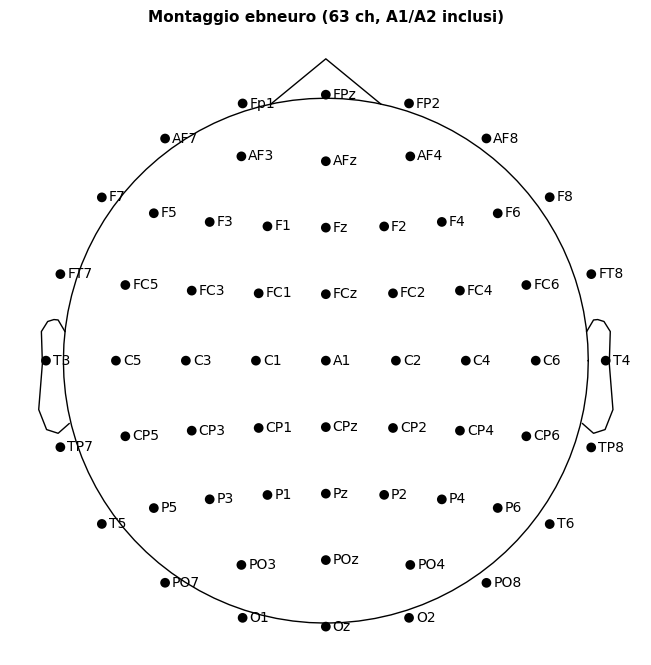

14:28:40 INFO     Montaggio salvato in /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg32_montage.png


In [5]:
try:
    fig = montage.plot(kind='topomap', show_names=True, show=False)
    fig.suptitle('Montaggio ebneuro (63 ch, A1/A2 inclusi)', y=1.02, fontsize=11, fontweight='bold')
    fig.savefig(FIG_DIR / 'eeg32_montage.png', dpi=140, bbox_inches='tight')
    plt.show()
    log.info(f'Montaggio salvato in {FIG_DIR / "eeg32_montage.png"}')
except Exception as e:
    log.warning(f'[INFO] Plot montaggio non riuscito ({e}); non bloccante.')


## §3 — Trasformazione CSD e confronto PSD prima/dopo

Carichiamo un campione di trial, costruiamo un `mne.EpochsArray` `(n_trials, 61, 384)` con
l'Info montato, e applichiamo `mne.preprocessing.compute_current_source_density`.

**Verifica chiave (ipotesi del collega).** Confrontiamo il **PSD medio** e un **topomap di
banda** *prima vs dopo* la CSD. Se la **banda beta (13–30 Hz)** ha potenza relativa maggiore
dopo lo sharpening, è una conferma diretta che la conduzione di volume stava "spalmando" e
attenuando i contributi locali in beta. Usiamo un sottoinsieme di trial (cap `MAX_TRIALS_CSD`)
per tenere la cella leggera.

> La CSD restituisce unità V/m² (non più µV): confrontiamo la **forma** dello spettro e la
> **frazione di potenza per banda**, non i valori assoluti.

In [6]:
# Bande di interesse
BANDS = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13),
         'beta': (13, 30), 'gamma': (30, 45)}
MAX_TRIALS_CSD = 400   # cap per leggerezza

def collect_sample_trials(max_trials, subjects=None):
    '''Raccoglie fino a max_trials (x 61x384) da .pt, opzionalmente filtrando soggetti.'''
    Xs, ys = [], []
    subj_pool = subjects if subjects is not None else ALL_SUBJ
    for sid in subj_pool:
        for sess, paths in subj_sess[sid].items():
            for p in paths:
                try:
                    x, y = load_trial(p)
                    if x.shape == (N_CHANNELS, N_SAMPLES):
                        Xs.append(x.astype(np.float32)); ys.append(y)
                except Exception:
                    continue
                if len(Xs) >= max_trials:
                    return np.stack(Xs), np.array(ys)
    return (np.stack(Xs), np.array(ys)) if Xs else (None, None)

def make_epochs(X, info):
    '''EpochsArray da (n,61,384). MNE assume Volt -> scaliamo i µV in V.'''
    return mne.EpochsArray(X.astype(np.float64) * 1e-6, info, verbose='ERROR')

def band_power_fractions(epochs, bands=BANDS, fmax=45.0):
    '''Frazione di potenza media per banda (media su trial e canali).'''
    psd = epochs.compute_psd(method='welch', fmin=1.0, fmax=fmax,
                             n_fft=min(256, N_SAMPLES), verbose='ERROR')
    psds, freqs = psd.get_data(return_freqs=True)   # (n_epochs, n_ch, n_freqs)
    mean_psd = psds.mean(axis=(0, 1))               # (n_freqs,)
    total = mean_psd.sum() + 1e-20
    frac = {b: mean_psd[(freqs >= lo) & (freqs < hi)].sum() / total for b, (lo, hi) in bands.items()}
    return freqs, mean_psd, frac

if not (DATA_OK and ALL_SUBJ):
    log.warning('[INFO] §3 saltata: dati per-trial non disponibili in locale. '
                'Eseguire sul server.')
    CSD_DONE = False
else:
    X_raw, y_raw = collect_sample_trials(MAX_TRIALS_CSD)
    log.info(f'Trial campionati per CSD: {X_raw.shape}')

    ep_raw = make_epochs(X_raw, info_csd)
    try:
        ep_csd = mne.preprocessing.compute_current_source_density(ep_raw.copy())
        CSD_DONE = True
        log.info('CSD applicata con successo (compute_current_source_density).')
    except Exception as e:
        log.error(f'[INFO] CSD fallita ({e}). Probabile mismatch posizioni/montaggio. '
                  'Verificare ch61 vs ordine dati (§2).')
        traceback.print_exc()
        CSD_DONE = False


14:28:40 INFO     Trial campionati per CSD: (400, 61, 384)
14:28:40 INFO     CSD applicata con successo (compute_current_source_density).


14:28:44 INFO     Beta frazione: RAW=0.1311 -> CSD=0.1318 (+0.0006). BETA SOPRAVVIVE DI PIU dopo CSD -> coerente con ipotesi volume conduction


Frazione di potenza per banda (media trial x canali):
  banda |      RAW |      CSD |  delta CSD-RAW
  delta |   0.5420 |   0.5422 |        +0.0002
  theta |   0.1355 |   0.1360 |        +0.0005
  alpha |   0.1199 |   0.1172 |        -0.0028
   beta |   0.1311 |   0.1318 |        +0.0006
  gamma |   0.0674 |   0.0687 |        +0.0013


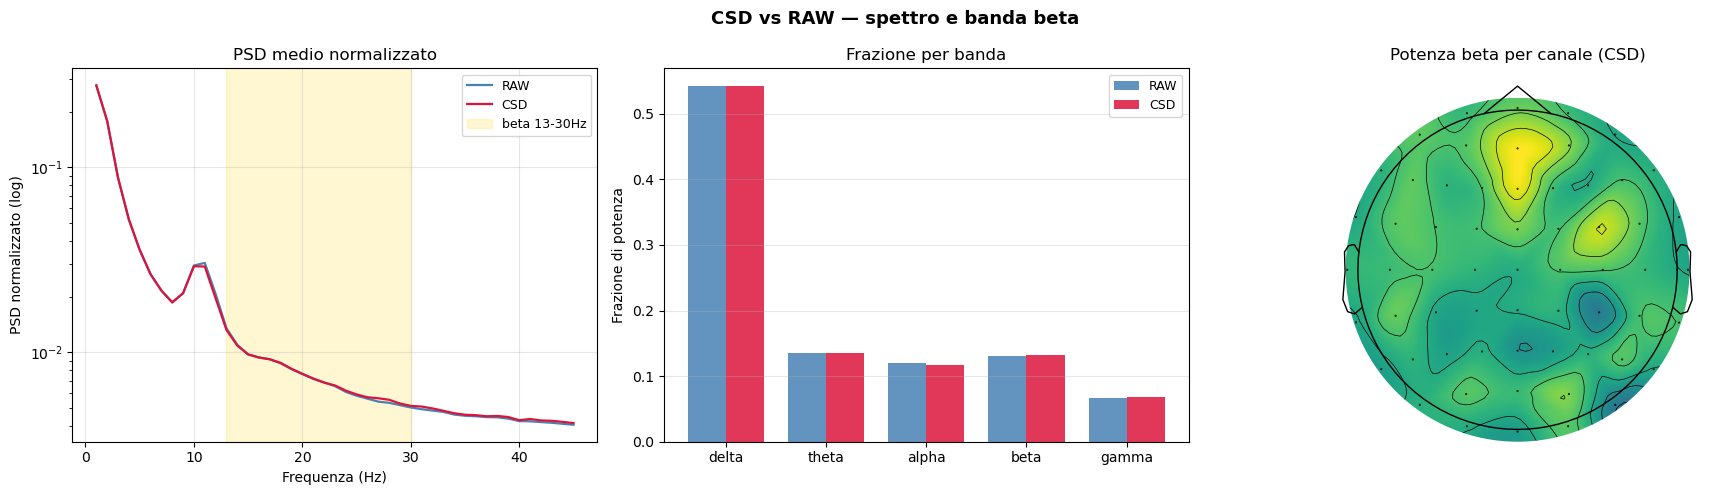

14:28:47 INFO     Figura salvata: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg32_csd_psd.png


In [7]:
if DATA_OK and ALL_SUBJ and CSD_DONE:
    freqs_r, psd_r, frac_r = band_power_fractions(ep_raw)
    freqs_c, psd_c, frac_c = band_power_fractions(ep_csd)

    print('Frazione di potenza per banda (media trial x canali):')
    print(f"{'banda':>7s} | {'RAW':>8s} | {'CSD':>8s} | {'delta CSD-RAW':>14s}")
    for b in BANDS:
        print(f'{b:>7s} | {frac_r[b]:8.4f} | {frac_c[b]:8.4f} | {frac_c[b]-frac_r[b]:+14.4f}')

    beta_gain = frac_c['beta'] - frac_r['beta']
    msg = ('BETA SOPRAVVIVE DI PIU dopo CSD -> coerente con ipotesi volume conduction'
           if beta_gain > 0 else
           'beta NON aumenta dopo CSD -> ipotesi non confermata su questo campione')
    log.info(f'Beta frazione: RAW={frac_r["beta"]:.4f} -> CSD={frac_c["beta"]:.4f} '
             f'({beta_gain:+.4f}). {msg}')

    # ── Figura confronto: PSD medio + barre frazione per banda + topomap beta ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('CSD vs RAW — spettro e banda beta', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.semilogy(freqs_r, psd_r / psd_r.sum(), label='RAW',  color='steelblue', lw=1.6)
    ax.semilogy(freqs_c, psd_c / psd_c.sum(), label='CSD',  color='crimson',   lw=1.6)
    ax.axvspan(13, 30, color='gold', alpha=0.18, label='beta 13-30Hz')
    ax.set_xlabel('Frequenza (Hz)'); ax.set_ylabel('PSD normalizzato (log)')
    ax.set_title('PSD medio normalizzato'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[1]
    bx = np.arange(len(BANDS)); w = 0.38
    ax.bar(bx - w/2, [frac_r[b] for b in BANDS], w, label='RAW', color='steelblue', alpha=0.85)
    ax.bar(bx + w/2, [frac_c[b] for b in BANDS], w, label='CSD', color='crimson',   alpha=0.85)
    ax.set_xticks(bx); ax.set_xticklabels(list(BANDS.keys()))
    ax.set_ylabel('Frazione di potenza'); ax.set_title('Frazione per banda')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    # Topomap potenza beta dopo CSD (per-canale)
    ax = axes[2]
    try:
        psd_obj = ep_csd.compute_psd(method='welch', fmin=13, fmax=30,
                                     n_fft=min(256, N_SAMPLES), verbose='ERROR')
        beta_per_ch = psd_obj.get_data().mean(axis=0).mean(axis=1)   # (61,)
        mne.viz.plot_topomap(beta_per_ch, ep_csd.info, axes=ax, show=False, cmap='viridis')
        ax.set_title('Potenza beta per canale (CSD)')
    except Exception as e:
        ax.text(0.5, 0.5, f'topomap non disponibile\n{e}', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        ax.set_axis_off()

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'eeg32_csd_psd.png', dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f'Figura salvata: {FIG_DIR / "eeg32_csd_psd.png"}')
else:
    log.warning('[INFO] Figura PSD CSD non generata (dati/CSD non disponibili).')


## §4 — Re-connettività e re-phenotyping su dati CSD

Ora il cuore del notebook. Per ogni soggetto:

1. Carichiamo i suoi trial, applichiamo la **CSD** (stesso Info montato),
2. Calcoliamo la connettività di **ampiezza `abs_pcc`** per trial (= |correlazione di Pearson|
   tra le serie temporali dei 61 canali, identico in spirito ad `abs_pcc` del progetto),
3. Mediamo sui trial → matrice `61×61` → **upper triangle (1830-dim)** = fingerprint soggetto.

Poi replichiamo **esattamente** la pipeline EEG_16b: `StandardScaler` → `PCA(20)` →
`KMeans(k=2)`. Confrontiamo i cluster CSD con i fenotipi autorevoli **C0/C1** (`subj2pheno`):

- **ARI** (`adjusted_rand_score`): quanto i cluster CSD concordano con C0/C1.
- **Silhouette**: quanto sono *netti* i cluster CSD. La domanda è se supera la baseline
  EEG_16b (**sil = 0.284**, non-CSD).

**Letture possibili.**
- ARI alto **e** silhouette > 0.284 → rimosso il volume conduction, i fenotipi si separano
  **meglio** → fenotipi più robusti, contributo rafforzato.
- ARI basso → la CSD **cambia** la struttura → i fenotipi C0/C1 erano (in parte) un artefatto
  di conduzione di volume. Anch'esso un finding forte.

> Per leggerezza c'è un cap `MAX_TRIALS_PHENO` di trial per soggetto e un minimo
> `MIN_TRIALS_SUBJ`. Tutto cache-ato in `models/eeg32/feat_csd_abs_pcc.npz`.

In [8]:
CKPT_DIR = project_root / 'models' / 'eeg32'; CKPT_DIR.mkdir(parents=True, exist_ok=True)
CSD_FEAT_CACHE = CKPT_DIR / 'feat_csd_abs_pcc.npz'

MAX_TRIALS_PHENO = 120   # cap trial/soggetto per la connettività CSD
MIN_TRIALS_SUBJ  = 10
triu_idx = np.triu_indices(N_CHANNELS, k=1)

def abs_pcc_from_epochs_data(data):
    '''data: (n_trials, 61, 384) post-CSD. Ritorna abs_pcc media (61,61).'''
    accum = np.zeros((N_CHANNELS, N_CHANNELS), dtype=np.float64)
    n = 0
    for trial in data:
        c = np.corrcoef(trial)               # (61,61) Pearson
        c = np.nan_to_num(c, nan=0.0)
        accum += np.abs(c)
        n += 1
    return accum / max(n, 1)

def compute_csd_feats():
    '''Calcola fingerprint abs_pcc post-CSD per soggetto (upper triangle 1830).'''
    feats, subj_ids = [], []
    for sid in tqdm(ALL_SUBJ, desc='CSD per soggetto'):
        Xs = []
        for sess, paths in subj_sess[sid].items():
            for p in paths:
                try:
                    x, _ = load_trial(p)
                    if x.shape == (N_CHANNELS, N_SAMPLES):
                        Xs.append(x.astype(np.float32))
                except Exception:
                    continue
                if len(Xs) >= MAX_TRIALS_PHENO:
                    break
            if len(Xs) >= MAX_TRIALS_PHENO:
                break
        if len(Xs) < MIN_TRIALS_SUBJ:
            continue
        X = np.stack(Xs)
        try:
            ep = make_epochs(X, info_csd)
            ep = mne.preprocessing.compute_current_source_density(ep)
            adj = abs_pcc_from_epochs_data(ep.get_data())
        except Exception as e:
            log.warning(f'  P{sid:03d}: CSD fallita ({e}) — soggetto saltato')
            continue
        feats.append(adj[triu_idx]); subj_ids.append(sid)
    return np.array(feats), subj_ids

if not (DATA_OK and ALL_SUBJ):
    log.warning('[INFO] §4 saltata: dati per-trial non disponibili in locale.')
    FEAT_CSD, SUBJ_CSD = None, None
elif CSD_FEAT_CACHE.exists():
    _c = np.load(CSD_FEAT_CACHE)
    FEAT_CSD, SUBJ_CSD = _c['feats'], _c['subj_ids'].tolist()
    log.info(f'Cache CSD caricata: {FEAT_CSD.shape}, {len(SUBJ_CSD)} soggetti')
else:
    FEAT_CSD, SUBJ_CSD = compute_csd_feats()
    if FEAT_CSD is not None and len(FEAT_CSD):
        np.savez(CSD_FEAT_CACHE, feats=FEAT_CSD, subj_ids=np.array(SUBJ_CSD))
        log.info(f'Feature CSD calcolate e cache-ate: {FEAT_CSD.shape}')


CSD per soggetto:   0%|          | 0/74 [00:00<?, ?it/s]

14:28:56 INFO     Feature CSD calcolate e cache-ate: (74, 1830)


14:28:56 INFO     Soggetti per clustering CSD (P022 escluso): 73
14:28:56 INFO     Varianza spiegata PCA CSD (<=20 comp): 71.7%
14:28:56 INFO     CSD k=2: silhouette=0.221 (ref EEG_16b=0.284) | sizes={np.int32(0): np.int64(47), np.int32(1): np.int64(26)}
14:28:56 INFO     ARI (cluster CSD vs C0/C1 autorevoli) su 73 soggetti: 0.481
14:28:56 INFO     VERDETTO silhouette: CSD non piu netti di EEG_16b
14:28:56 INFO     VERDETTO ARI: cluster CSD DIVERSI da C0/C1 (volume conduction influenzava i fenotipi)


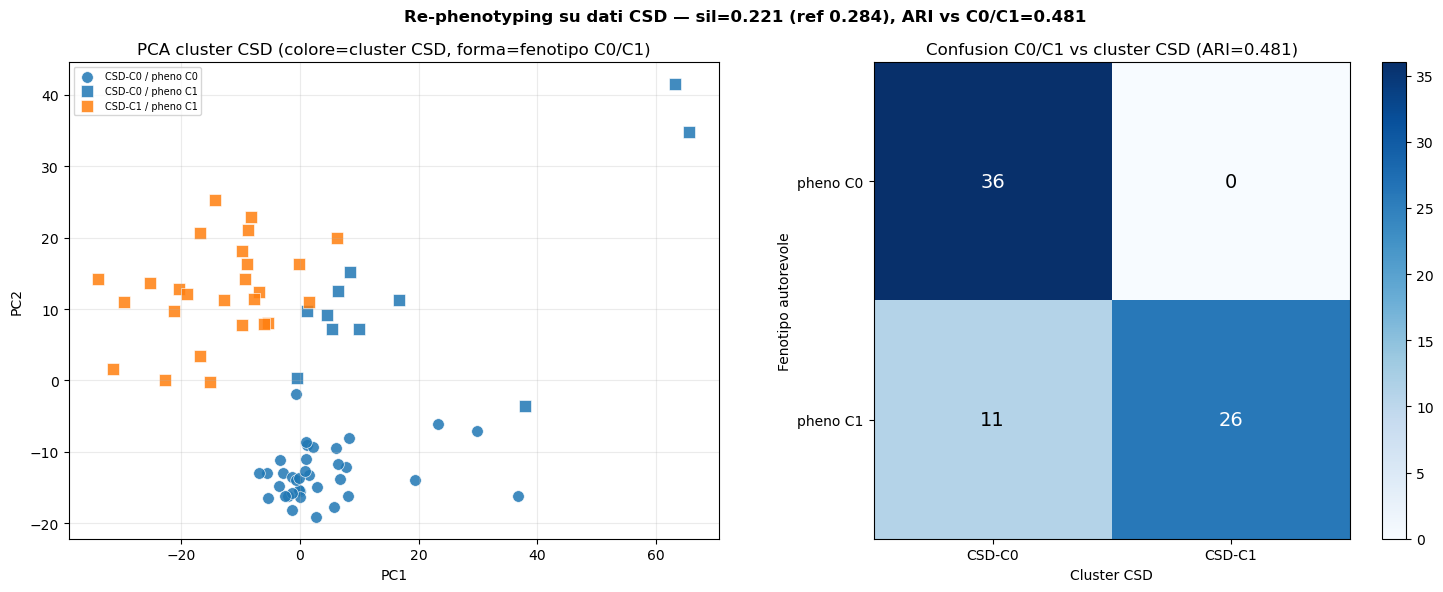

14:28:56 INFO     Figura salvata: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg32_rephenotyping.png
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


ari_vs_pheno,0.48147
sil_csd,0.22133
sil_ref_eeg16b,0.284


14:29:00 INFO     Metriche clustering loggate su W&B.


In [9]:
# ── Clustering k=2 sui fingerprint CSD + confronto con C0/C1 ──────────────────
if FEAT_CSD is None or not len(FEAT_CSD):
    log.warning('[INFO] Clustering CSD non eseguibile (feature mancanti). Eseguire sul server.')
else:
    # Escludiamo P022 per parita' con EEG_16b
    keep = [i for i, s in enumerate(SUBJ_CSD) if s not in PHENO_EXCLUDE]
    feat_use = FEAT_CSD[keep]
    subj_use = [SUBJ_CSD[i] for i in keep]
    log.info(f'Soggetti per clustering CSD (P022 escluso): {len(subj_use)}')

    X = StandardScaler().fit_transform(feat_use)
    pca = PCA(n_components=min(20, len(subj_use) - 1), random_state=RANDOM_SEED)
    Z = pca.fit_transform(X)
    log.info(f'Varianza spiegata PCA CSD (<=20 comp): {pca.explained_variance_ratio_.sum():.1%}')

    LABELS_CSD = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
    sil_csd = silhouette_score(Z, LABELS_CSD)
    sizes = dict(zip(*np.unique(LABELS_CSD, return_counts=True)))
    log.info(f'CSD k=2: silhouette={sil_csd:.3f} (ref EEG_16b={SIL_REF_EEG16B}) | sizes={sizes}')

    # Allineamento con fenotipi autorevoli su soggetti in comune
    common = [s for s in subj_use if s in subj2pheno]
    lbl_csd_c = np.array([LABELS_CSD[subj_use.index(s)] for s in common])
    lbl_ref_c = np.array([subj2pheno[s] for s in common])
    ari = adjusted_rand_score(lbl_ref_c, lbl_csd_c)
    log.info(f'ARI (cluster CSD vs C0/C1 autorevoli) su {len(common)} soggetti: {ari:.3f}')

    # Verdetti
    netter = sil_csd > SIL_REF_EEG16B
    concorda = ari > 0.5
    log.info('VERDETTO silhouette: ' + ('CSD piu netti di EEG_16b (fenotipi piu robusti)'
             if netter else 'CSD non piu netti di EEG_16b'))
    log.info('VERDETTO ARI: ' + ('cluster CSD ~= C0/C1 (struttura stabile)' if concorda
             else 'cluster CSD DIVERSI da C0/C1 (volume conduction influenzava i fenotipi)'))

    # ── Figura: PCA 2D + confusion C0/C1 vs cluster CSD ──────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Re-phenotyping su dati CSD — sil={sil_csd:.3f} (ref {SIL_REF_EEG16B}), '
                 f'ARI vs C0/C1={ari:.3f}', fontsize=12, fontweight='bold')

    ax = axes[0]
    pheno_of = np.array([subj2pheno.get(s, -1) for s in subj_use])
    markers = {0: 'o', 1: 's', -1: 'x'}
    colors = plt.cm.tab10(np.linspace(0, 0.15, 2))
    for c in (0, 1):
        for ph in (0, 1, -1):
            mask = (LABELS_CSD == c) & (pheno_of == ph)
            if mask.any():
                ax.scatter(Z[mask, 0], Z[mask, 1], color=colors[c], marker=markers[ph],
                           s=70, alpha=0.85, edgecolors='white', linewidths=0.5,
                           label=f'CSD-C{c} / pheno {"C"+str(ph) if ph>=0 else "n/a"}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title('PCA cluster CSD (colore=cluster CSD, forma=fenotipo C0/C1)')
    ax.legend(fontsize=7, loc='best'); ax.grid(alpha=0.25)

    ax = axes[1]
    cm = np.zeros((2, 2), dtype=int)
    for r, c in zip(lbl_ref_c, lbl_csd_c):
        cm[r, c] += 1
    im = ax.imshow(cm, cmap='Blues'); plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['CSD-C0', 'CSD-C1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['pheno C0', 'pheno C1'])
    ax.set_xlabel('Cluster CSD'); ax.set_ylabel('Fenotipo autorevole')
    ax.set_title(f'Confusion C0/C1 vs cluster CSD (ARI={ari:.3f})')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'eeg32_rephenotyping.png', dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f'Figura salvata: {FIG_DIR / "eeg32_rephenotyping.png"}')

    # ── W&B opzionale: solo metriche di clustering ───────────────────────────
    try:
        import wandb
        run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                         name='eeg32_csd_rephenotyping', reinit='finish_previous',
                         config={'notebook': 'EEG_32', 'metric': DATA_METRIC,
                                 'n_subj': len(subj_use), 'csd': True})
        run.summary['sil_csd'] = float(sil_csd)
        run.summary['sil_ref_eeg16b'] = SIL_REF_EEG16B
        run.summary['ari_vs_pheno'] = float(ari)
        run.finish()
        log.info('Metriche clustering loggate su W&B.')
    except Exception as e:
        log.info(f'[INFO] W&B non loggato (opzionale): {e}')


## §5 — (Opzionale, leggero) decoding `concr4`: CSD vs non-CSD

Un classificatore **lineare** su feature di **banda** (potenza per banda per canale, 61×5 =
305 feature) per `concr4`, split **subject-independent** standard, su un sottoinsieme di trial.
Obiettivo: vedere se la CSD aiuta *marginalmente* il decoding. Resta volutamente leggero —
**non** è il modello principale della tesi (che è DL end-to-end sul raw). Se il calcolo
risultasse troppo pesante sul server, ridurre `MAX_TR_PER_SUBJ_DEC` o saltare la cella.

**Lettura attesa.** Se il decoding **non** migliora con la CSD, è un'ulteriore conferma che
il limite è la **scarsità di segnale** (data-limited), non la rappresentazione spaziale.

In [10]:
from sklearn.linear_model import LogisticRegression

MAX_TR_PER_SUBJ_DEC = 60   # cap trial/soggetto per il decoding leggero

def bandpower_features(epochs):
    '''Ritorna (n_trials, 61*5) frazioni di potenza per banda per canale.'''
    psd = epochs.compute_psd(method='welch', fmin=1.0, fmax=45.0,
                             n_fft=min(256, N_SAMPLES), verbose='ERROR')
    psds, freqs = psd.get_data(return_freqs=True)   # (n_ep, n_ch, n_f)
    feats = []
    for lo, hi in BANDS.values():
        sel = (freqs >= lo) & (freqs < hi)
        feats.append(psds[:, :, sel].sum(axis=2))   # (n_ep, n_ch)
    F = np.stack(feats, axis=2)                      # (n_ep, n_ch, n_band)
    F = F / (F.sum(axis=(1, 2), keepdims=True) + 1e-20)
    return F.reshape(F.shape[0], -1)                 # (n_ep, 305)

def gather_split(subjects, apply_csd):
    Xl, yl = [], []
    for sid in subjects:
        Xs, ys = [], []
        for sess, paths in subj_sess.get(sid, {}).items():
            for p in paths:
                try:
                    x, y = load_trial(p)
                    if x.shape == (N_CHANNELS, N_SAMPLES) and y in label2cluster:
                        Xs.append(x.astype(np.float32)); ys.append(label2cluster[y])
                except Exception:
                    continue
                if len(Xs) >= MAX_TR_PER_SUBJ_DEC:
                    break
            if len(Xs) >= MAX_TR_PER_SUBJ_DEC:
                break
        if not Xs:
            continue
        ep = make_epochs(np.stack(Xs), info_csd)
        if apply_csd:
            try:
                ep = mne.preprocessing.compute_current_source_density(ep)
            except Exception:
                continue
        Xl.append(bandpower_features(ep)); yl.extend(ys)
    return (np.concatenate(Xl), np.array(yl)) if Xl else (None, None)

def run_decoding(apply_csd):
    Xtr, ytr = gather_split(SUBJ_TRAIN, apply_csd)
    Xte, yte = gather_split(SUBJ_TEST,  apply_csd)
    if Xtr is None or Xte is None:
        return None
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(sc.transform(Xtr), ytr)
    return balanced_accuracy_score(yte, clf.predict(sc.transform(Xte)))

if not (DATA_OK and ALL_SUBJ):
    log.warning('[INFO] §5 (decoding) saltata: dati non disponibili. Eseguire sul server.')
else:
    chance = 1.0 / N_CLASSES
    bacc_raw = run_decoding(apply_csd=False)
    bacc_csd = run_decoding(apply_csd=True)
    log.info(f'Decoding concr4 (chance={chance:.3f}) | RAW bAcc={bacc_raw} | CSD bAcc={bacc_csd}')
    if bacc_raw is not None and bacc_csd is not None:
        delta = bacc_csd - bacc_raw
        log.info(f'Delta CSD-RAW = {delta:+.4f} -> ' +
                 ('CSD aiuta marginalmente' if delta > 0.005 else
                  'CSD NON migliora -> coerente con limite data-limited'))

14:29:38 INFO     Decoding concr4 (chance=0.250) | RAW bAcc=0.24755280900238885 | CSD bAcc=0.24702456740271866
14:29:38 INFO     Delta CSD-RAW = -0.0005 -> CSD NON migliora -> coerente con limite data-limited


## §6 — Conclusioni attese / come leggere i risultati

Questo notebook chiude il cerchio sul **"perché l'hypergraph non ha funzionato"** con una
verifica diretta (CSD/Laplaciano) invece di una citazione. **Ogni esito è informativo.**

**(a) Re-phenotyping — §4.**
- *Cluster più netti dopo CSD* (`silhouette > 0.284` di EEG_16b) **e** ARI alto vs C0/C1 →
  rimosso il volume conduction, i fenotipi si separano **meglio**: fenotipi più robusti,
  **contributo rafforzato**.
- *ARI basso* → i cluster cambiano: parte della struttura C0/C1 era un **artefatto** di
  conduzione di volume. Finding altrettanto forte (riscrive l'interpretazione dei fenotipi).

**(b) Banda beta — §3.**
- Se la **frazione di potenza beta (13–30 Hz) aumenta dopo CSD**, è la **conferma diretta**
  dell'ipotesi del collega: il volume conduction "spalmava" e attenuava i contributi locali,
  e lo sharpening li recupera. Spiega *meccanicisticamente* perché la diffusione spaziale
  dell'hypergraph era controproducente.

**(c) Decoding — §5.**
- Se il decoding **non** migliora con la CSD, è un'**ulteriore conferma data-limited**: il
  collo di bottiglia è la scarsità di segnale informativo, non la rappresentazione spaziale.
  (Coerente con `imagined-speech-ceiling-thesis` del vault collega.)

**Caveat metodologico (§2).** Tutto poggia sull'**assunzione** che l'ordine dei 61 canali nei
`.pt` coincida con `ch61` (ebneuro senza A1/A2). `chan_names.json` non la valida (solo indici).
Se sul server emergesse un ordine diverso, **tutte** le analisi CSD vanno reinterpretate.

**Prossimo passo.** Se la CSD migliora i fenotipi o salva la beta, vale la pena ri-addestrare
un DHSLP/encoder **sul segnale CSD** (input pre-sharpened) e verificare se l'hypergraph, a quel
punto, smette di essere NULL.